# Dipendenze

In [ ]:
# Clone del repository DeOldify e setup ambiente
!git clone https://github.com/jantic/DeOldify.git
%cd DeOldify

# pesi preaddestrati
!mkdir -p models
!wget https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth -O ./models/ColorizeArtistic_gen.pth

Cloning into 'DeOldify'...
remote: Enumerating objects: 2620, done.
remote: Counting objects: 100% (583/583), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 2620 (delta 501), reused 459 (delta 459), pack-reused 2037 (from 1)
Receiving objects: 100% (2620/2620), 69.67 MiB | 24.51 MiB/s, done.
Resolving deltas: 100% (1210/1210), done.
/content/DeOldify
--2025-09-28 20:18:16--  https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth
Resolving data.deepai.org (data.deepai.org)... 195.181.163.203, 2400:52e0:1a02::1210:1
Connecting to data.deepai.org (data.deepai.org)|195.181.163.203|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 255144681 (243M) [application/octet-stream]
Saving to: ‘./models/ColorizeArtistic_gen.pth’

./models/ColorizeAr 100%[===================>] 243.32M  5.16MB/s    in 50s     

2025-09-28 20:19:06 (4.88 MB/s) - ‘./models/ColorizeArtistic_gen.pth’ saved [255144681/255144681]



controllo versioni

In [ ]:

!pip install -r requirements-colab.txt
!pip install ipycanvas

!pip install -q opencv-python matplotlib
!pip install -q opencv-python pycocotools matplotlib onnxruntime
!pip uninstall -y numpy scipy
!pip install numpy==1.23.5 scipy==1.10.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.4/631.4 kB 19.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.3/237.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.4 MB/s eta 0:00:00


In [ ]:
import numpy
import scipy
print(numpy.__version__)
print(scipy.__version__)


1.23.5
1.10.1


DeOldify&SAM github

In [ ]:

%cd /content/


!git clone https://github.com/jantic/DeOldify.git || echo "DeOldify già presente"


!git clone https://github.com/facebookresearch/segment-anything.git SAM || echo "SAM già presente"

/content
fatal: destination path 'DeOldify' already exists and is not an empty directory.
DeOldify già presente
Cloning into 'SAM'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 304 (delta 2), reused 1 (delta 1), pack-reused 299 (from 2)
Receiving objects: 100% (304/304), 18.31 MiB | 2.90 MiB/s, done.
Resolving deltas: 100% (159/159), done.


Copia pesi SAM da drive a colab in /content/SAM/checkpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/SAM/checkpoints
!cp "/content/drive/MyDrive/checkout SAM/sam_vit_h_4b8939.pth" /content/SAM/checkpoints/
!cp "/content/drive/MyDrive/checkout SAM/sam_vit_b_01ec64.pth" /content/SAM/checkpoints/
!cp "/content/drive/MyDrive/checkout SAM/sam_vit_l_0b3195.pth" /content/SAM/checkpoints/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

# Import e patch load

In [ ]:

%cd /content/DeOldify


import sys
sys.path.append('/content/DeOldify')

import torch


_original_torch_load = torch.load
def patched_torch_load(*args, **kwargs):
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)
torch.load = patched_torch_load


import deoldify
from deoldify import device
from deoldify._device import DeviceId
device.set(DeviceId.GPU0)

# Importa il colorizer
from deoldify.visualize import get_image_colorizer
colorizer = get_image_colorizer(artistic=True)


# Estrazione frame

In [ ]:
import cv2
import os

def extract_frames(video_path, output_dir, target_size=(512, 512)):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized_frame = cv2.resize(gray_frame, target_size, interpolation=cv2.INTER_AREA)
        rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_GRAY2RGB)

        frame_name = f"frame_{frame_count:04d}.jpg"
        output_path = os.path.join(output_dir, frame_name)
        cv2.imwrite(output_path, rgb_frame)

        frame_count += 1

    cap.release()
    print(f"[INFO] Estratti {frame_count} frame in {output_dir}")


# Colorizzazione

In [ ]:
from pathlib import Path

def colorize_frame(input_path, output_path, render_factor=35):
    os.makedirs(output_path, exist_ok=True)
  
    input_path = Path(input_path)
    output_path = Path(output_path)
    colorizer.plot_transformed_image(
        path=input_path,
        results_dir=output_path,
        render_factor=render_factor,
        display_render_factor=False,
        figsize=(8, 8)
    )


# Colorizzazione di un video

In [ ]:
from pathlib import Path
import os
import cv2

def colorize_all_frames(input_folder, output_folder, render_factor=25):
    os.makedirs(output_folder, exist_ok=True)
    input_folder = Path(input_folder)
    output_folder = Path(output_folder)

    frames = sorted(input_folder.glob("*.jpg"))
    print(f"[INFO] Trovati {len(frames)} frame da colorare")

    for frame_path in frames:
        frame_name = frame_path.name 
        output_path = output_folder / frame_name
        colorize_frame_single_output(frame_path, output_path, render_factor=render_factor)
        print(f"[DONE] Colorizzato {frame_name}")
def colorize_frame_single_output(input_path, output_path, render_factor=25):
    from deoldify.visualize import get_image_colorizer
    colorizer = get_image_colorizer(artistic=True)
    colorizer.plot_transformed_image(path=str(input_path), results_dir=output_path.parent, render_factor=render_factor, display_render_factor=False)
    
    generated_name = output_path.parent / input_path.name
    if generated_name.exists():
        os.rename(generated_name, output_path)
def frames_to_video(frames_folder, output_video_path, fps=25, frame_size=(512, 512)):
    frames_folder = Path(frames_folder)
    frames = sorted(frames_folder.glob("*.jpg")) 

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, frame_size)

    for frame_path in frames:
        frame = cv2.imread(str(frame_path))
        if frame is None:
            print(f"[WARN] Impossibile leggere frame {frame_path}")
            continue
        video_writer.write(frame)

    video_writer.release()
    print(f"[INFO] Video salvato in {output_video_path}")


# Segmentazione

## Segmentazione Base

In [ ]:
import sys
sys.path.append('/content/SAM')
from segment_anything import sam_model_registry, SamPredictor
import torch
import numpy as np
import cv2
from matplotlib import pyplot as plt

model_type = "vit_l"
# Percorso ai pesi SAM
sam_checkpoint_h = "/content/SAM/checkpoints/sam_vit_h_4b8939.pth"
sam_checkpoint_b = "/content/SAM/checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint_l = "/content/SAM/checkpoints/sam_vit_l_0b3195.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint_l)
sam.to(device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1024, out_features=4096, bias=True)
          (lin2): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [ ]:
# Carica immagine
image_path = "/content/drive/MyDrive/Video_Output/test_1/frame_0023.jpg"
image_bgr = cv2.imread(image_path)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# Predittore
predictor = SamPredictor(sam)
predictor.set_image(image)

Canvas(height=512, width=512)

Click: 238.01144426642253,239.01927214465553
Click: 259.01176470588234,365.0211947814145
Click: 436.01446555275805,357.0210727092393
Click: 394.0138246738384,203.01872281986724
4 punti selezionati: [(238.01144426642253, 239.01927214465553), (259.01176470588234, 365.0211947814145), (436.01446555275805, 357.0210727092393), (394.0138246738384, 203.01872281986724)]
Bounding box calcolata da 4 punti: [(238.01144426642253, 203.01872281986724), (436.01446555275805, 365.0211947814145)]


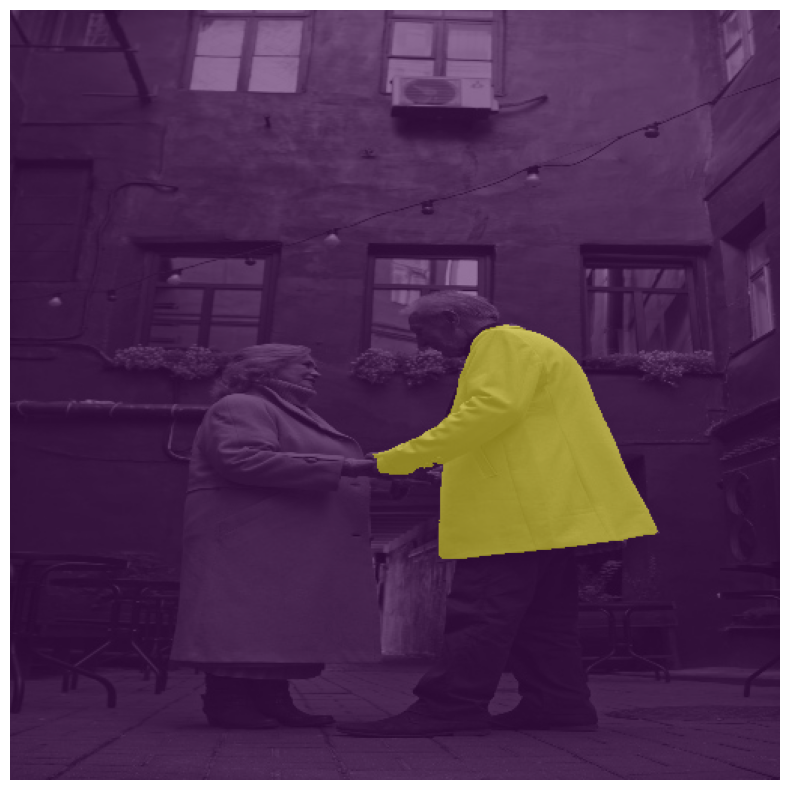

In [ ]:
from ipycanvas import Canvas
import numpy as np
from PIL import Image
from google.colab import output
output.disable_custom_widget_manager()
from google.colab import output
output.enable_custom_widget_manager()

image = np.array(Image.open('/content/drive/MyDrive/Video_Output/test_1/frame_0023.jpg'))
h, w, _ = image.shape

canvas = Canvas(width=w, height=h)
canvas.put_image_data(image)

def segment_by_bbox(bbox):
    global mask  
    x0, y0 = bbox[0]
    x1, y1 = bbox[1]
    box = np.array([x0, y0, x1, y1])

    masks, scores, logits = predictor.predict(
        box=box[None, :],
        multimask_output=False,
    )

    mask = masks[0]  

    # Visualizza maschera sovrapposta
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.imshow(mask, alpha=0.5)
    plt.axis('off')
    plt.show()



def segment_by_polygon(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x0, x1 = min(xs), max(xs)
    y0, y1 = min(ys), max(ys)
    bbox = [(x0, y0), (x1, y1)]
    print(f"Bounding box calcolata da 4 punti: {bbox}")
    segment_by_bbox(bbox)

points = []

def handle_click(x, y):
    global points
    print(f"Click: {x},{y}")
    points.append((x, y))
    if len(points) == 4:
        print("4 punti selezionati:", points)
        segment_by_polygon(points)
        points = []

canvas.on_mouse_down(handle_click)

canvas 

[✅] Immagine salvata con tinta trasparente: /content/drive/MyDrive/Video_Output/final_custom/frame_0023.jpg


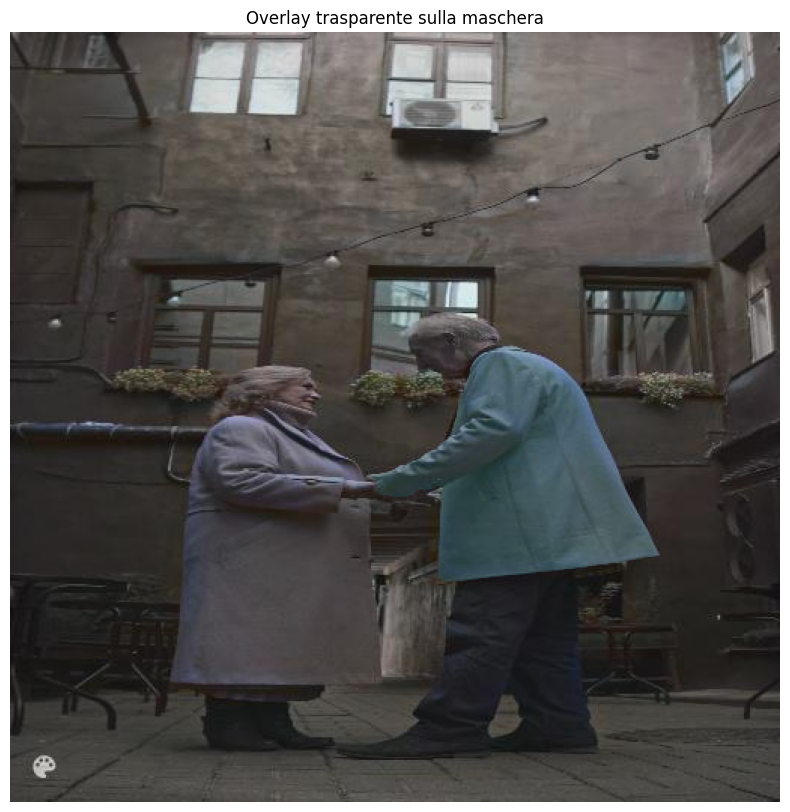

In [ ]:

from PIL import Image
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt


frame_name = "frame_0023.jpg"
user_color = (0, 255, 255)  # Colore RGB da sovrapporre (es. ciano)
alpha_value = 0.1  


colorized_image_path = f"/content/drive/MyDrive/Video_Output/test_1_colorized/{frame_name}"
output_custom_path = f"/content/drive/MyDrive/Video_Output/final_custom/{frame_name}"


os.makedirs(os.path.dirname(output_custom_path), exist_ok=True)


assert 'mask' in locals(), " Devi prima creare la maschera usando SAM"


def apply_soft_color_overlay(original_path, mask, user_color, output_path, alpha=0.4):
    image = cv2.imread(original_path)
    if image is None:
        raise FileNotFoundError(f"Immagine non trovata: {original_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if mask.dtype != np.bool_:
        mask = mask.astype(bool)

    # Applica il colore come overlay trasparente
    blended = image.copy()
    for c in range(3):  # per R, G, B
        blended[:, :, c] = np.where(
            mask,
            (1 - alpha) * image[:, :, c] + alpha * user_color[c],
            image[:, :, c]
        ).astype(np.uint8)

   
    output_img = Image.fromarray(blended)
    output_img.save(output_path)
    print(f"[✅] Immagine salvata con tinta trasparente: {output_path}")

    # Visualizza
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis('off')
    plt.title("Overlay trasparente sulla maschera")
    plt.show()

apply_soft_color_overlay(colorized_image_path, mask, user_color, output_custom_path, alpha=alpha_value)


# Tracking SEGMENTATION ON VIDEO

## COLORIZZAZIONE VIDEO CON DEOLDIFY

In [ ]:
import numpy as np
import cv2
import os
import shutil
import matplotlib.pyplot as plt


frames_dir_color = "/content/tmp_frames_color"     
start_frame_index = 23
num_tracking_frames = 10
output_video_path = "/content/drive/MyDrive/Video_Output/final_video_colorized_overlay.mp4"
user_color = (0, 255, 255)  # colore overlay (ciano)
alpha_value = 0.3           # trasparenza overlay

mask_uint8 = (mask * 255).astype(np.uint8)

# --- carica frame iniziale  ---
first_frame_path = os.path.join(frames_dir_color, f"frame_{start_frame_index:04d}.png")
first_frame = cv2.imread(first_frame_path)
prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)


points_to_track = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=5, mask=mask_uint8)

if points_to_track is None:
    raise ValueError("Nessun punto di tracking trovato nella maschera!")

print(f"Punti di tracking trovati: {len(points_to_track)}")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
frame_height, frame_width = first_frame.shape[:2]
out = cv2.VideoWriter(output_video_path, fourcc, 20.0, (frame_width, frame_height))

# --- funzione overlay colore maschera su frame ---
def apply_soft_color_overlay_to_frame(image, mask, user_color, alpha=0.3):
    if mask.dtype != np.bool_:
        mask = mask.astype(bool)
    blended = image.copy()
    for c in range(3):
        blended[:, :, c] = np.where(
            mask,
            (1 - alpha) * image[:, :, c] + alpha * user_color[c],
            image[:, :, c]
        ).astype(np.uint8)
    return blended

prev_points = points_to_track
prev_mask = mask_uint8

for i in range(start_frame_index, start_frame_index + num_tracking_frames + 1):
    frame_path = os.path.join(frames_dir_color, f"frame_{i:04d}.png")
    if not os.path.exists(frame_path):
        print(f"Frame non trovato: {frame_path}")
        continue

    frame = cv2.imread(frame_path)
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if i == start_frame_index:
        overlay_frame = apply_soft_color_overlay_to_frame(frame, prev_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)
        plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
        plt.title(f'Frame {i} con overlay')
        plt.axis('off')
        plt.show()
        continue

    next_points, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, frame_gray, prev_points, None)
    good_new = next_points[status == 1]
    good_old = prev_points[status == 1]

    if len(good_old) >= 3:
        matrix, _ = cv2.estimateAffinePartial2D(good_old, good_new)
        transformed_mask = cv2.warpAffine(prev_mask, matrix, (frame.shape[1], frame.shape[0]))

        overlay_frame = apply_soft_color_overlay_to_frame(frame, transformed_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)

        plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
        plt.title(f'Tracking Frame {i} con overlay')
        plt.axis('off')
        plt.show()

        prev_gray = frame_gray.copy()
        prev_points = good_new.reshape(-1, 1, 2)
        prev_mask = transformed_mask
    else:
        print(f" Troppi pochi punti nel frame {i}, uso maschera precedente")
        overlay_frame = apply_soft_color_overlay_to_frame(frame, prev_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)

out.release()
print(f" Video finale con overlay salvato in: {output_video_path}")


shutil.rmtree(frames_dir_bn)
shutil.rmtree(frames_dir_color)
print(f"Cartelle temporanee rimosse")


## TRACCIARE LA MASCHERA

Canvas(height=512, width=512)

Click: 118.00961318379493,262.01962310215913
Click: 235.01139848935682,265.01966887922487
Click: 250.01162737468528,435.02226291294727
Click: 102.00936903944458,433.0222323949035
4 punti selezionati: [(118.00961318379493, 262.01962310215913), (235.01139848935682, 265.01966887922487), (250.01162737468528, 435.02226291294727), (102.00936903944458, 433.0222323949035)]
Bounding box calcolata da 4 punti: [(102.00936903944458, 262.01962310215913), (250.01162737468528, 435.02226291294727)]


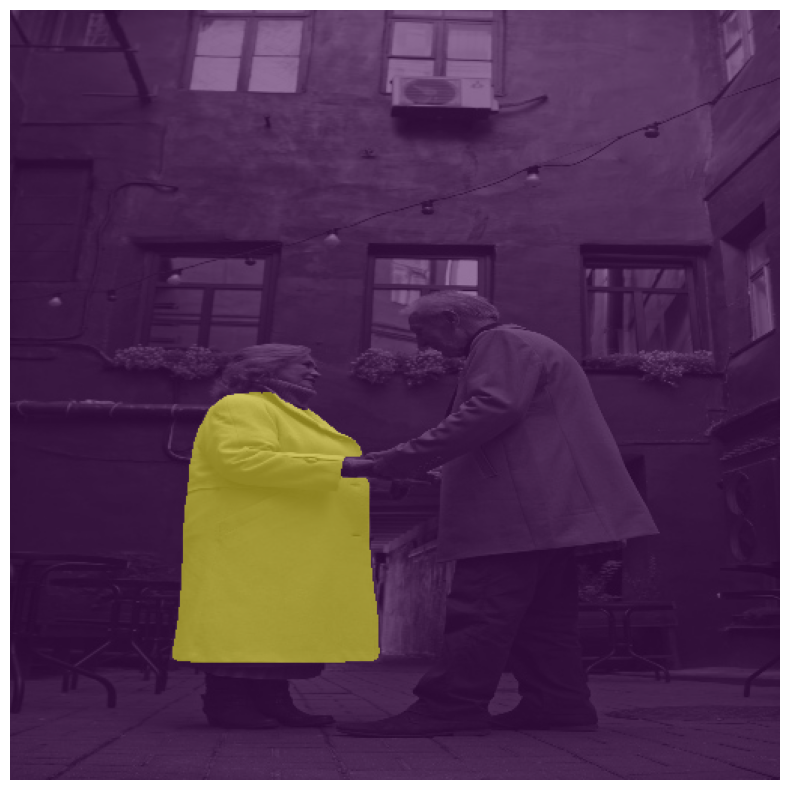

In [ ]:
from ipycanvas import Canvas
import numpy as np
from PIL import Image
from google.colab import output
output.disable_custom_widget_manager()
from google.colab import output
output.enable_custom_widget_manager()

image_path = "/content/drive/MyDrive/Video_Output/test_1/frame_0023.jpg"
image_bgr = cv2.imread(image_path)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# Predittore
predictor = SamPredictor(sam)
predictor.set_image(image)
image = np.array(Image.open('/content/drive/MyDrive/Video_Output/test_1/frame_0023.jpg'))
h, w, _ = image.shape

canvas = Canvas(width=w, height=h)
canvas.put_image_data(image)

def segment_by_bbox(bbox):
    global mask  
    x0, y0 = bbox[0]
    x1, y1 = bbox[1]
    box = np.array([x0, y0, x1, y1])

    masks, scores, logits = predictor.predict(
        box=box[None, :],
        multimask_output=False,
    )

    mask = masks[0] 

    #  maschera sovrapposta
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.imshow(mask, alpha=0.5)
    plt.axis('off')
    plt.show()


def segment_by_polygon(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x0, x1 = min(xs), max(xs)
    y0, y1 = min(ys), max(ys)
    bbox = [(x0, y0), (x1, y1)]
    print(f"Bounding box calcolata da 4 punti: {bbox}")
    segment_by_bbox(bbox)

points = []

def handle_click(x, y):
    global points
    print(f"Click: {x},{y}")
    points.append((x, y))
    if len(points) == 4:
        print("4 punti selezionati:", points)
        segment_by_polygon(points)
        points = []

canvas.on_mouse_down(handle_click)

canvas 

## TRACKING DELLA MASCHERA E SALVATAGGIO VIDEO

✅ Estratti 100 frame in /content/tmp_frames
Punti di tracking trovati: 200


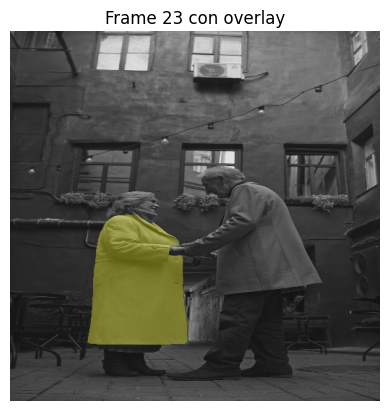

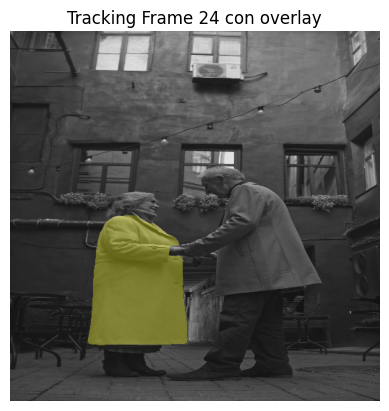

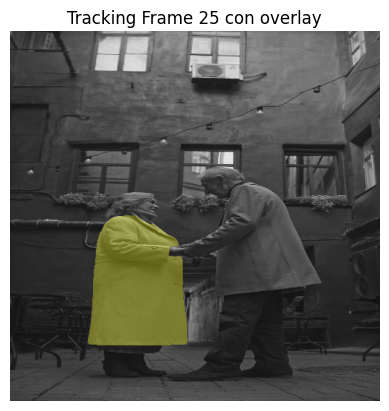

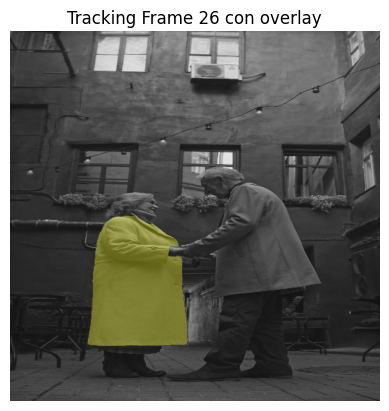

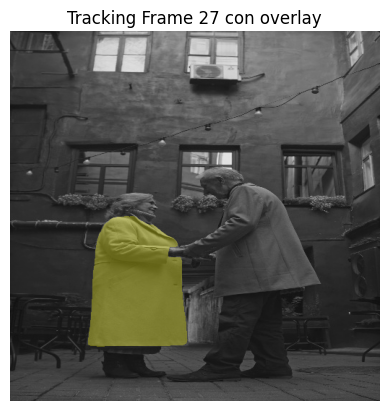

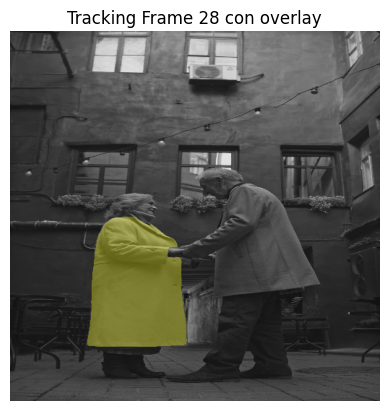

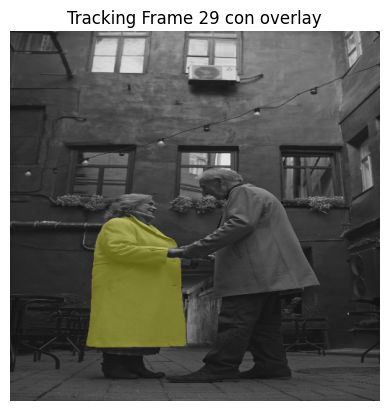

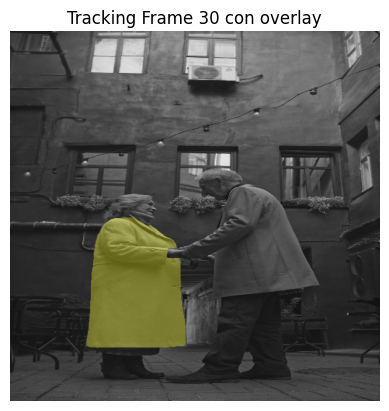

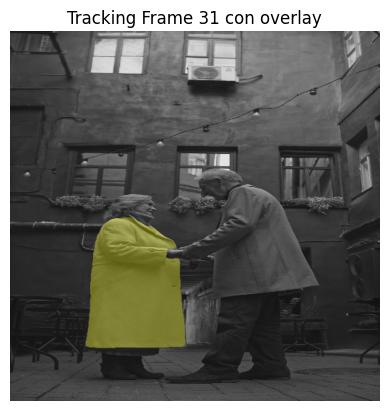

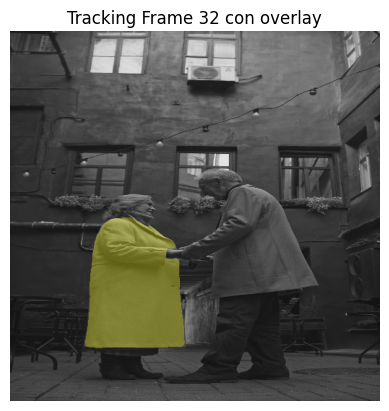

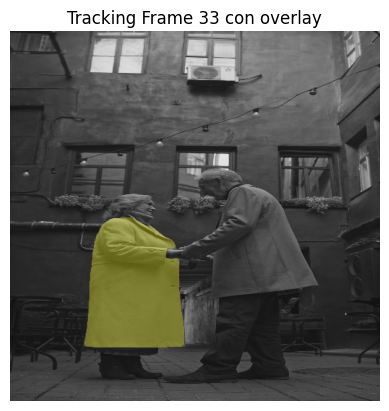

🎬 Video finale con overlay salvato in: /content/drive/MyDrive/Video_Output/tracked_output_colorized.mp4
🧹 Cartella temporanea rimossa: /content/tmp_frames


In [ ]:
import cv2
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt


video_path = "/content/drive/MyDrive/VIDEO/amoreB&W.mp4"
tmp_frames_dir = "/content/tmp_frames"
max_frames = 100
resize_to = (512, 512)
start_frame_index = 23
num_tracking_frames = 10
output_video_path = "/content/drive/MyDrive/Video_Output/tracked_output_colorized.mp4"
user_color = (0, 255, 255)  # colore overlay (ciano)
alpha_value = 0.3  # trasparenza overlay


if os.path.exists(tmp_frames_dir):
    shutil.rmtree(tmp_frames_dir)
os.makedirs(tmp_frames_dir, exist_ok=True)


cap = cv2.VideoCapture(video_path)
frame_count = 0
while cap.isOpened() and frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    if resize_to:
        frame = cv2.resize(frame, resize_to)
    cv2.imwrite(os.path.join(tmp_frames_dir, f"frame_{frame_count:04d}.jpg"), frame)
    frame_count += 1
cap.release()
print(f" Estratti {frame_count} frame in {tmp_frames_dir}")

first_frame = cv2.imread(os.path.join(tmp_frames_dir, f"frame_{start_frame_index:04d}.jpg"))
prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

mask_uint8 = (mask * 255).astype(np.uint8)

points_to_track = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=5, mask=mask_uint8)

if points_to_track is None:
    raise ValueError("Nessun punto di tracking trovato nella maschera!")

print(f"Punti di tracking trovati: {len(points_to_track)}")


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
frame_height, frame_width = resize_to[1], resize_to[0]
out = cv2.VideoWriter(output_video_path, fourcc, 20.0, (frame_width, frame_height))

# --- funzione overlay ---
def apply_soft_color_overlay_to_frame(image, mask, user_color, alpha=0.3):
    if mask.dtype != np.bool_:
        mask = mask.astype(bool)
    blended = image.copy()
    for c in range(3):
        blended[:, :, c] = np.where(
            mask,
            (1 - alpha) * image[:, :, c] + alpha * user_color[c],
            image[:, :, c]
        ).astype(np.uint8)
    return blended

prev_points = points_to_track
prev_mask = mask_uint8

for i in range(start_frame_index, start_frame_index + num_tracking_frames + 1):
    frame_path = os.path.join(tmp_frames_dir, f"frame_{i:04d}.jpg")
    if not os.path.exists(frame_path):
        print(f"⚠️ Frame non trovato: {frame_path}")
        continue

    frame = cv2.imread(frame_path)

    # Primo frame:  overlay direttamente
    if i == start_frame_index:
        overlay_frame = apply_soft_color_overlay_to_frame(frame, prev_mask > 127, user_color, alpha_value)
        prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        out.write(overlay_frame)
        plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
        plt.title(f'Frame {i} con overlay')
        plt.axis('off')
        plt.show()
        continue

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    next_points, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, frame_gray, prev_points, None)

    good_new = next_points[status == 1]
    good_old = prev_points[status == 1]

    if len(good_old) >= 3:
        matrix, _ = cv2.estimateAffinePartial2D(good_old, good_new)
        transformed_mask = cv2.warpAffine(prev_mask, matrix, (frame.shape[1], frame.shape[0]))

        overlay_frame = apply_soft_color_overlay_to_frame(frame, transformed_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)

        plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
        plt.title(f'Tracking Frame {i} con overlay')
        plt.axis('off')
        plt.show()

        prev_gray = frame_gray.copy()
        prev_points = good_new.reshape(-1, 1, 2)
        prev_mask = transformed_mask
    else:
        print(f" Troppi pochi punti nel frame {i}, uso maschera precedente")
        overlay_frame = apply_soft_color_overlay_to_frame(frame, prev_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)

out.release()
print(f"Video finale con overlay salvato in: {output_video_path}")

shutil.rmtree(tmp_frames_dir)
print(f"Cartella temporanea rimossa: {tmp_frames_dir}")


#FINALE CAZZO

## ESTRAI COLORIZZAZIONE VIDEO

In [ ]:
import cv2
import os
import shutil

video_path = "/content/drive/MyDrive/VIDEO/amoreB&W.mp4"
tmp_bw_dir = "/content/tmp_bw_frames"

# Pulizia cartella temporanea
if os.path.exists(tmp_bw_dir):
    shutil.rmtree(tmp_bw_dir)
os.makedirs(tmp_bw_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_idx = 0
max_frames = 100  

while cap.isOpened() and frame_idx < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    frame_path = os.path.join(tmp_bw_dir, f"frame_{frame_idx:04d}.jpg")
    cv2.imwrite(frame_path, frame)
    frame_idx += 1

cap.release()
print(f"✅ Estratti {frame_idx} frame B&W in {tmp_bw_dir}")


✅ Estratti 100 frame B&W in /content/tmp_bw_frames


#COLORIZZA FRAME ESTRATTI CON DEOLDIFY

Da velocizzare

In [ ]:
from pathlib import Path
import os
import cv2
import torch
from deoldify.visualize import get_image_colorizer


device = 'cuda' if torch.cuda.is_available() else 'cpu'

# === CONFIG ===
tmp_bw_dir = "/content/tmp_bw_frames"          
tmp_color_dir = "/content/tmp_color_frames"   
output_video_path = "/content/output_video.mp4" 

# === SETUP ===
os.makedirs(tmp_color_dir, exist_ok=True)
colorizer = get_image_colorizer(artistic=True)



def colorize_all_frames(input_folder, output_folder, render_factor=25):
    input_folder = Path(input_folder)
    output_folder = Path(output_folder)
    os.makedirs(output_folder, exist_ok=True)

    frames = sorted(input_folder.glob("*.jpg"))
    print(f"[INFO] Trovati {len(frames)} frame da colorare")

    for frame_path in frames:
        frame_name = frame_path.name
        output_path = output_folder / frame_name
        colorize_frame_single_output(frame_path, output_path, render_factor=render_factor)
        print(f"[DONE] Colorizzato {frame_name}")

def colorize_frame_single_output(input_path, output_path, render_factor=25):
    colorizer.plot_transformed_image(
        path=str(input_path),
        results_dir=output_path.parent,
        render_factor=render_factor,
        display_render_factor=False
    )
   
    generated = output_path.parent / input_path.name
    if generated.exists():
        os.rename(generated, output_path)

def frames_to_video(frames_folder, output_video_path, fps=25):
    frames_folder = Path(frames_folder)
    frames = sorted(frames_folder.glob("*.jpg"))

    if not frames:
        print("[ERROR] Nessun frame trovato per creare il video.")
        return

    first_frame = cv2.imread(str(frames[0]))
    h, w = first_frame.shape[:2]
    frame_size = (w, h)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, frame_size)

    for frame_path in frames:
        frame = cv2.imread(str(frame_path))
        if frame is None:
            print(f"[WARN] Impossibile leggere frame {frame_path}")
            continue
        video_writer.write(frame)

    video_writer.release()
    print(f"[INFO] Video salvato in {output_video_path}")

# === ESECUZIONE ===

colorize_all_frames(tmp_bw_dir, tmp_color_dir, render_factor=25)
frames_to_video(tmp_color_dir, output_video_path, fps=25)


## USA IL 1 FRAME COLORATO E TRACCIAMO MASCHERA SAM

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ipycanvas import Canvas
from google.colab import output

output.disable_custom_widget_manager()
output.enable_custom_widget_manager()

frame_index = 23
frame_path = f"/content/tmp_color_frames/frame_{frame_index:04d}.jpg"
image_bgr = cv2.imread(frame_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

h, w, _ = image_rgb.shape
canvas = Canvas(width=w, height=h)
canvas.put_image_data(image_rgb)

def segment_by_bbox(bbox):
    global mask  
    x0, y0 = bbox[0]
    x1, y1 = bbox[1]
    box = np.array([x0, y0, x1, y1])
    masks, scores, logits = predictor.predict(box=box[None, :], multimask_output=False)
    mask = masks[0]

    plt.figure(figsize=(10,10))
    plt.imshow(image_rgb)
    plt.imshow(mask, alpha=0.5)
    plt.axis('off')
    plt.show()


canvas  


## Traccia la maschera sui frame colorati, applica overlay colorato e ricostruisci video finale

In [ ]:
import cv2
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt

# Parametri
tmp_color_dir = "/content/tmp_color_frames"
max_frames = len(os.listdir(tmp_color_dir))  
start_frame_index = 23 
num_tracking_frames = max_frames - start_frame_index  
output_video_path = "/content/drive/MyDrive/Video_Output/tracked_final_video.mp4"
user_color = (0, 255, 255)  
alpha_value = 0.3

assert 'mask' in globals(), "Devi eseguire la cella di segmentazione e creare la maschera."

mask_uint8 = (mask * 255).astype(np.uint8)


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
sample_frame = cv2.imread(os.path.join(tmp_color_dir, f"frame_{start_frame_index:04d}.jpg"))
frame_height, frame_width = sample_frame.shape[:2]
out = cv2.VideoWriter(output_video_path, fourcc, 20.0, (frame_width, frame_height))


prev_gray = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2GRAY)
points_to_track = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=5, mask=mask_uint8)
if points_to_track is None:
    raise RuntimeError("Nessun punto di tracking trovato nella maschera!")

prev_points = points_to_track
prev_mask = mask_uint8.copy()

def apply_overlay(image, mask, color, alpha):
    if mask.dtype != np.bool_:
        mask = mask.astype(bool)
    overlayed = image.copy()
    for c in range(3):
        overlayed[:, :, c] = np.where(
            mask,
            (1-alpha)*image[:, :, c] + alpha*color[c],
            image[:, :, c]
        ).astype(np.uint8)
    return overlayed

for i in range(start_frame_index, start_frame_index + num_tracking_frames):
    frame_path = os.path.join(tmp_color_dir, f"frame_{i:04d}.jpg")
    if not os.path.exists(frame_path):
        print(f"⚠️ Frame {i} non trovato.")
        continue

    frame = cv2.imread(frame_path)
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if i == start_frame_index:
        overlay_frame = apply_overlay(frame, prev_mask > 127, user_color, alpha_value)
        out.write(overlay_frame)
        prev_gray = frame_gray
        continue

   
    next_points, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, frame_gray, prev_points, None)
    good_new = next_points[status == 1]
    good_old = prev_points[status == 1]

    if len(good_old) >= 3:
        matrix, _ = cv2.estimateAffinePartial2D(good_old, good_new)
        transformed_mask = cv2.warpAffine(prev_mask, matrix, (frame.shape[1], frame.shape[0]))
        overlay_frame = apply_overlay(frame, transformed_mask > 127, user_color, alpha_value)


        prev_points = good_new.reshape(-1, 1, 2)
        prev_mask = transformed_mask
        prev_gray = frame_gray.copy()
    else:
        print(f"⚠️ Troppi pochi punti nel frame {i}, uso maschera precedente")
        overlay_frame = apply_overlay(frame, prev_mask > 127, user_color, alpha_value)

    out.write(overlay_frame)

out.release()
print(f"🎬 Video finale salvato in: {output_video_path}")


# Utilizzo delle funzioni main:

estrazione dei frame

In [ ]:
extract_frames(
    video_path="/content/drive/MyDrive/VIDEO/amoreB&W.mp4",
    output_dir="/content/drive/MyDrive/Video_Output/test_1",
    target_size=(512, 512)
)


colorizzazione di 1 solo frame

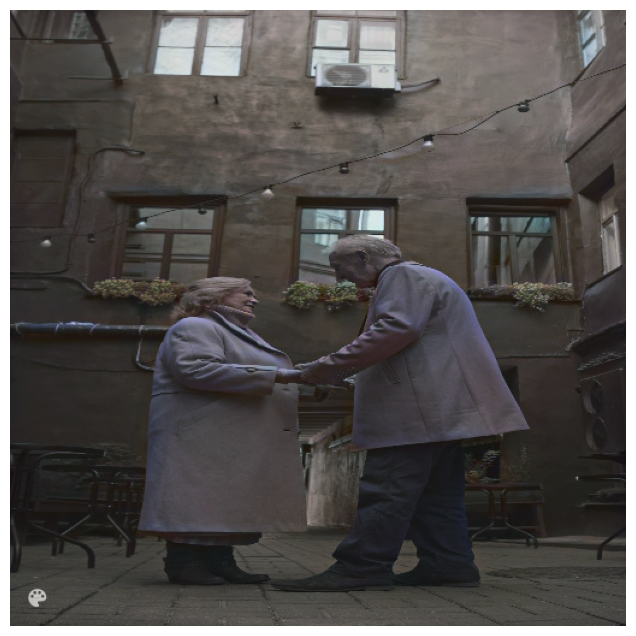

In [ ]:

input_frame = "/content/drive/MyDrive/Video_Output/test_1/frame_0023.jpg"
output_folder = "/content/drive/MyDrive/Video_Output/test_1_colorized"

colorize_frame(input_frame, output_folder)

colorizzazione di tutti i frame

In [ ]:
import glob

input_folder = "/content/drive/MyDrive/Video_Output/test_1"
output_base_folder = "/content/drive/MyDrive/Video_Output/colorized_all"

os.makedirs(output_base_folder, exist_ok=True)

frame_paths = sorted(glob.glob(os.path.join(input_folder, "*.jpg")))

for frame_path in frame_paths:
    frame_name = os.path.basename(frame_path)
    output_folder = os.path.join(output_base_folder, os.path.splitext(frame_name)[0])
    colorize_frame(frame_path, output_folder)


Colorizzazione video

In [ ]:
video_input = "/content/drive/MyDrive/VIDEO/amoreB&W.mp4"
frames_folder = "/content/drive/MyDrive/Video_Output/test_1"
colorized_folder = "/content/drive/MyDrive/Video_Output/test_1_colorati"
video_output = "/content/drive/MyDrive/Video_Output/Video_colorized/amore_colorized.mp4"


extract_frames(video_input, frames_folder, target_size=(512, 512))

# 2) colorizzaframe
colorize_all_frames(frames_folder, colorized_folder, render_factor=25)

# 3) ricostruisci video
frames_to_video(colorized_folder, video_output, fps=25, frame_size=(512, 512))


Colorizzazione di un secondo di video (24fp)

In [ ]:
import cv2
import os
from deoldify.visualize import get_image_colorizer
from deoldify import device
from deoldify._device import DeviceId
from PIL import Image
import shutil


device.set(DeviceId.GPU0)
colorizer = get_image_colorizer(artistic=True)


video_input = "/content/drive/MyDrive/VIDEO/amoreB&W.mp4"
frames_folder = "/content/drive/MyDrive/Video_Output/test_1"
colorized_folder = "/content/drive/MyDrive/Video_Output/test_1_colorati"
video_output = "/content/drive/MyDrive/Video_Output/Video_colorized/amore_colorized.mp4"


shutil.rmtree(frames_folder, ignore_errors=True)
shutil.rmtree(colorized_folder, ignore_errors=True)
os.makedirs(frames_folder, exist_ok=True)
os.makedirs(colorized_folder, exist_ok=True)

# 1) estrazuione primi 24 frame
cap = cv2.VideoCapture(video_input)
count = 0
while count < 24:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (512, 512))
    frame_path = os.path.join(frames_folder, f"frame_{count:04d}.jpg")
    cv2.imwrite(frame_path, frame)
    count += 1
cap.release()

# 2) Colorizzazione i frame
for filename in sorted(os.listdir(frames_folder)):
    if filename.endswith(".jpg"):
        input_path = os.path.join(frames_folder, filename)
        output = colorizer.get_transformed_image(
        path=input_path, render_factor=25
      )
    output.save(os.path.join(colorized_folder, filename))


# 3) Ricostruzione il video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(video_output, fourcc, 25, (512, 512))

for filename in sorted(os.listdir(colorized_folder)):
    frame = cv2.imread(os.path.join(colorized_folder, filename))
    video_writer.write(frame)

video_writer.release()
